In [12]:
#Import neccessary libraries
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

In [13]:
#Function 3
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 3.csv') 
columns = ['Input 1', 'Input 2','Input 3', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
data

,Input 1,Input 2,Input 3,Outputs
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


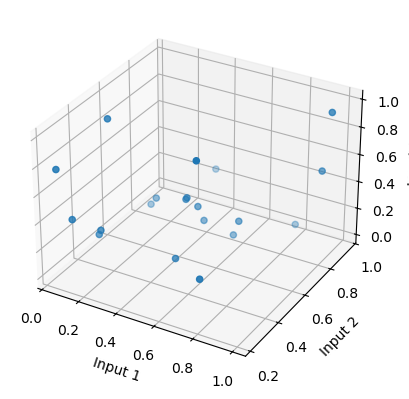

In [14]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3']])
Y = np.array(data[['Outputs']])

#Visualise already explored points
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2])

ax.set_xlabel("Input 1")
ax.set_ylabel("Input 2")
ax.set_zlabel("Input 3")

plt.show()

In [15]:
# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Input 3,Outputs
Input 1,1.000000,0.545021,0.023066,-0.141891
Input 2,0.545021,1.000000,-0.208922,-0.109354
Input 3,0.023066,-0.208922,1.000000,-0.599305
Outputs,-0.141891,-0.109354,-0.599305,1.000000


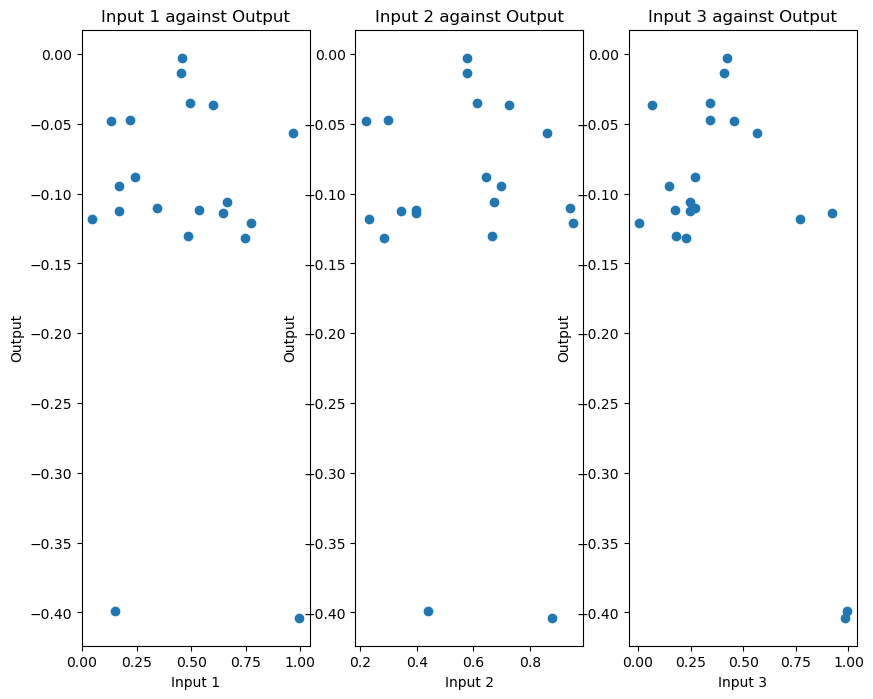

In [16]:
#Plotting each Input against the output
fig, ax = plt.subplots(1,3, figsize = (10,8))
ax[0].scatter(X[:,0], Y)
ax[1].scatter(X[:,1], Y)
ax[2].scatter(X[:,2], Y)

#Creating titles and axis labels
ax[0].set_title('Input 1 against Output')
ax[1].set_title('Input 2 against Output')
ax[2].set_title('Input 3 against Output')

ax[0].set_xlabel('Input 1')
ax[0].set_ylabel('Output')

ax[1].set_xlabel('Input 2')
ax[1].set_ylabel('Output')

ax[2].set_xlabel('Input 3')
ax[2].set_ylabel('Output')
plt.show()

In [17]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale=1.0, length_scale_bounds= (1e-2,1e1), nu = nu)
gp_best = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
gp_best.fit(X,Y)
#Use latin hypercube sampling to create a set of candidate points 
d = 3
n = 100000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Fit the GP regressor to the candidate points
mu, std = gp_best.predict(grid, return_std = True)

In [18]:
#Calculating expected improvement
best_y = np.max(Y)
eta = 0.01
z = (mu - best_y - eta) / (std + 1e-12)
ei = (mu - best_y - eta ) * norm.cdf(z) + std * norm.pdf(z)
#Find Candidate value that maximises expected improvement 
best_idx = np.argmax(ei)
x_next = grid[best_idx]
np.round(x_next,6)

array([0.558321, 0.588294, 0.499907])

In [25]:
#Calculate UCB as comparison
beta = 2.5 #set exploration parameter
UCB = mu + beta * std
#Find Candidate value that maximises UCB
best_idx = np.argmax(UCB)
x_next = grid[best_idx]
np.round(x_next,6)

array([0.583115, 0.709624, 0.569389])